In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df = pd.read_csv(
    "/Users/vivekrai/Desktop/CS597 S2/Prototype/results/balanced_tree_algorithm_comparison_20260413_222438_experiment_results.csv"
)
print(df.columns)
df.head()

Index(['algorithm', 'num_requests', 'num_nodes', 'data_uniformity', 'seed',
       'topology_type', 'balanced_tree_branching_factor', 'request_idx',
       'node_idx', 'timestamp', 'included_modalities', 'needed_modalities',
       'selected_nodes', 'modality_assignment', 'cost',
       'successful_calculation', 'missing_modalities', 'time_taken',
       'fairness_index', 'successful_calculation_overall',
       'failed_calculation_count', 'failed_calculations'],
      dtype='str')


,algorithm,num_requests,num_nodes,data_uniformity,seed,topology_type,balanced_tree_branching_factor,request_idx,node_idx,timestamp,...,selected_nodes,modality_assignment,cost,successful_calculation,missing_modalities,time_taken,fairness_index,successful_calculation_overall,failed_calculation_count,failed_calculations
0,proposed,10,10,1.0,1,balanced_tree,2,0,5,2013-08-28,...,"[8, 9, 6]","{'temp_max': 6, 'wind': 9, 'precipitation': 8}",8.0,True,[],0.025973,0.643796,1.0,0,[]
1,proposed_fast,10,10,1.0,1,balanced_tree,2,0,5,2013-08-28,...,"[8, 9, 6]","{'temp_max': 6, 'wind': 9, 'precipitation': 8}",8.0,True,[],0.010047,0.643796,1.0,0,[]
2,random,10,10,1.0,1,balanced_tree,2,0,5,2013-08-28,...,"[8, 9, 6]","{'wind': 9, 'precipitation': 8, 'temp_max': 6}",8.0,True,[],0.023935,0.729655,1.0,0,[]
3,ilp,10,10,1.0,1,balanced_tree,2,0,5,2013-08-28,...,"[8, 9, 6]","{'temp_max': 6, 'precipitation': 8, 'wind': 9}",8.0,True,[],0.950058,0.643796,1.0,0,[]
4,proposed,10,10,1.0,1,balanced_tree,2,1,5,2015-11-29,...,[6],{'temp_max': 6},2.0,True,[],0.025973,0.643796,1.0,0,[]


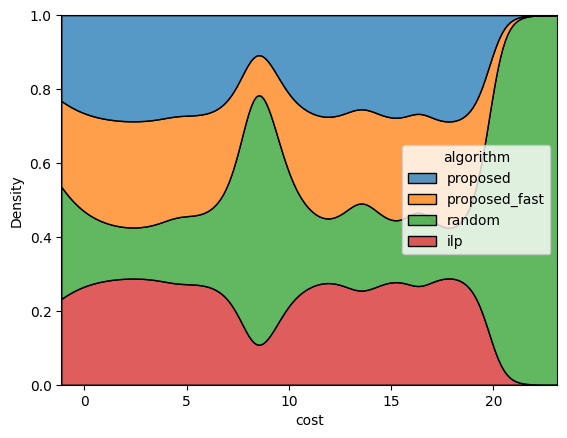

In [4]:
sns.kdeplot(df, x="cost", hue="algorithm", multiple="fill")
plt.show()

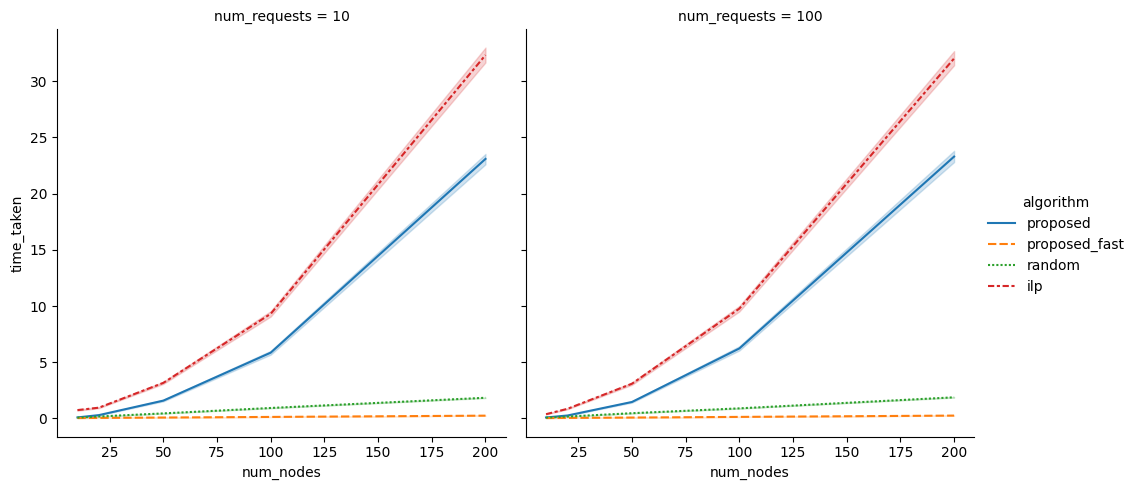

In [27]:
sns.relplot(
    df,
    kind="line",
    col="num_requests",
    col_wrap=2,
    x="num_nodes",
    y="time_taken",
    hue="algorithm",
    style="algorithm",
)
plt.show()

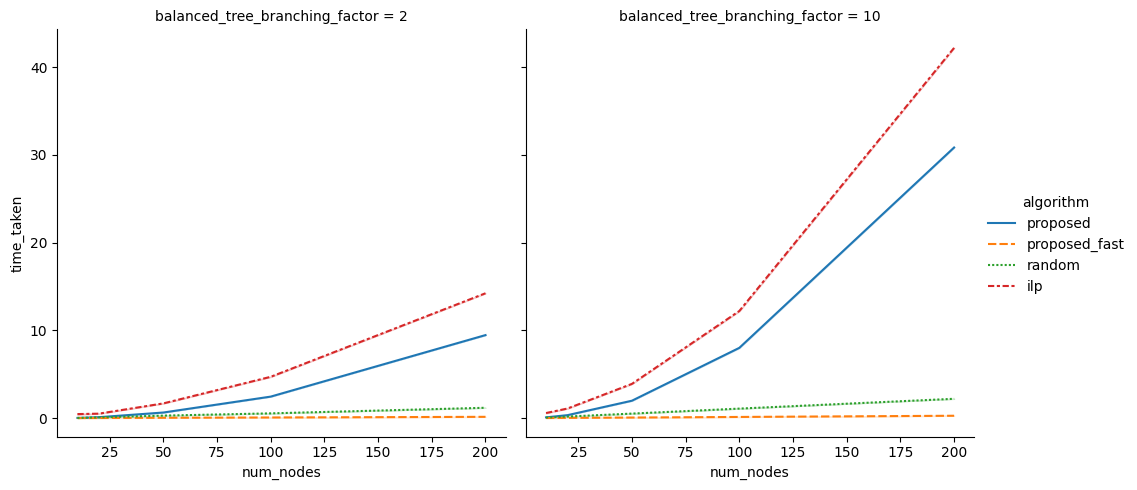

In [28]:
sns.relplot(
    df,
    kind="line",
    col="balanced_tree_branching_factor",
    col_wrap=2,
    x="num_nodes",
    y="time_taken",
    hue="algorithm",
    style="algorithm",
)
plt.show()

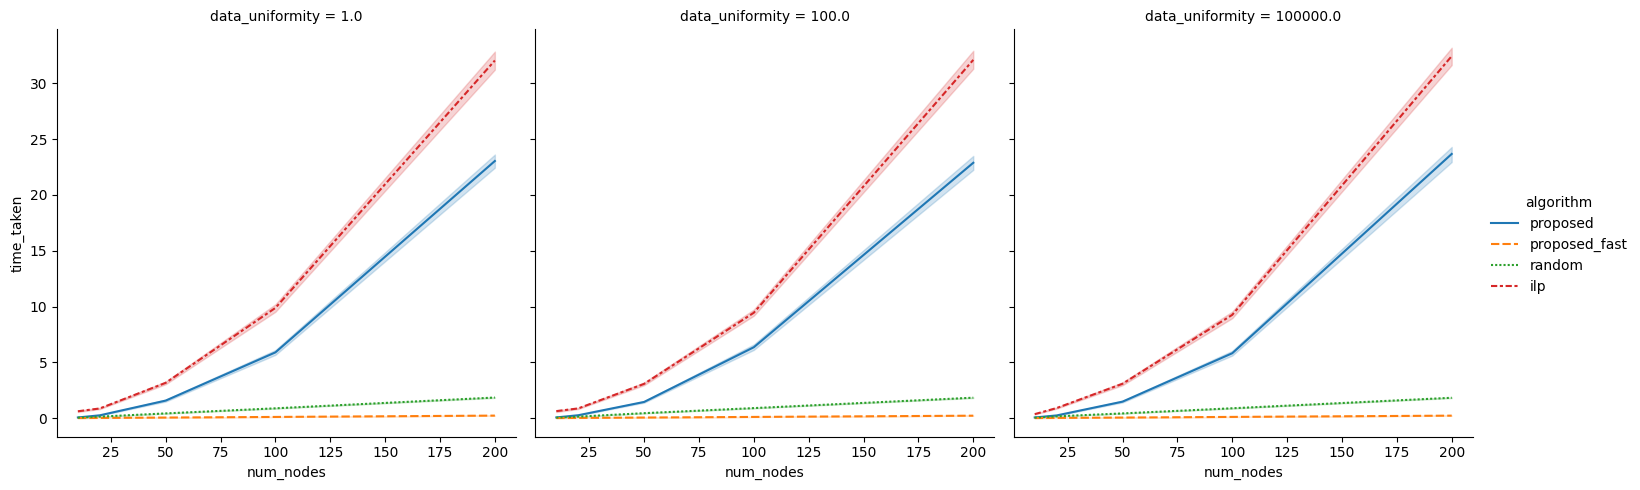

In [ ]:
sns.relplot(
    df,
    kind="line",
    col="data_uniformity",
    col_wrap=3,
    x="num_nodes",
    y="time_taken",
    hue="algorithm",
    style="algorithm",
)
plt.show()

## Key Findings

In [ ]:
run_summary = df[
    [
        "algorithm",
        "num_requests",
        "num_nodes",
        "data_uniformity",
        "seed",
        "balanced_tree_branching_factor",
        "time_taken",
        "fairness_index",
        "successful_calculation_overall",
        "failed_calculation_count",
    ]
].drop_duplicates()

run_summary.head()

,algorithm,num_requests,num_nodes,data_uniformity,seed,balanced_tree_branching_factor,time_taken,fairness_index,successful_calculation_overall,failed_calculation_count
0,proposed,10,10,1.0,1,2,0.025973,0.643796,1.0,0
1,proposed_fast,10,10,1.0,1,2,0.010047,0.643796,1.0,0
2,random,10,10,1.0,1,2,0.023935,0.729655,1.0,0
3,ilp,10,10,1.0,1,2,0.950058,0.643796,1.0,0
40,proposed,10,10,1.0,1,10,0.080823,0.693907,1.0,0


In [ ]:
run_summary.shape

(240, 10)

In [23]:
algorithm_runtime_means = (
    run_summary.groupby("algorithm")[
        [
            "time_taken",
            "fairness_index",
            "successful_calculation_overall",
            "failed_calculation_count",
        ]
    ]
    .mean()
)

algorithm_runtime_means

,time_taken,fairness_index,successful_calculation_overall,failed_calculation_count
algorithm,,,,
ilp,8.151860,0.419575,1.0,0.0
proposed,5.392374,0.349469,1.0,0.0
proposed_fast,0.081348,0.349469,1.0,0.0
random,0.618384,0.748490,1.0,0.0


In [24]:
algorithm_cost_means = (
    df.groupby("algorithm")[["cost", "successful_calculation"]]
    .mean()
)

algorithm_cost_means

,cost,successful_calculation
algorithm,,
ilp,8.755326,1.0
proposed,8.755326,1.0
proposed_fast,8.755326,1.0
random,10.047619,1.0


In [25]:
algorithm_means = pd.concat([algorithm_runtime_means, algorithm_cost_means], axis=1)

algorithm_means

,time_taken,fairness_index,successful_calculation_overall,failed_calculation_count,cost,successful_calculation
algorithm,,,,,,
ilp,8.151860,0.419575,1.0,0.0,8.755326,1.0
proposed,5.392374,0.349469,1.0,0.0,8.755326,1.0
proposed_fast,0.081348,0.349469,1.0,0.0,8.755326,1.0
random,0.618384,0.748490,1.0,0.0,10.047619,1.0


In [29]:
algorithm_runtime_max = (
    run_summary.groupby("algorithm")[
        [
            "time_taken",
            "fairness_index",
            "successful_calculation_overall",
            "failed_calculation_count",
        ]
    ]
    .max()
)

algorithm_runtime_max

,time_taken,fairness_index,successful_calculation_overall,failed_calculation_count
algorithm,,,,
ilp,43.290931,0.859060,1.0,0
proposed,31.956581,0.789671,1.0,0
proposed_fast,0.291239,0.789671,1.0,0
random,2.258783,0.836356,1.0,0
